In [422]:
import numpy as np

In [423]:
x=np.array([2])
w=np.array([3])
y=x**2
y+=1
x

array([2])

In [424]:
d1 = {1: 1, 2: 2}
d2 = {4: 'ha!', 3: 3}
d1['d2'] = d2
d1

{1: 1, 2: 2, 'd2': {4: 'ha!', 3: 3}}

In [425]:
import torch
t=torch.tensor([[2,2,4],[1,1,9]])
t=t.unsqueeze(2)
t=t.unsqueeze(3)
t=t.repeat((1,1,3,3))
t.shape

torch.Size([2, 3, 3, 3])

In [426]:
t=torch.tensor([[1,0,0],[0,1,0],[0,0,1],[0,1,0],[0,0,1],[0,0,1],[1,0,0],[0,1,0],[1,0,0],[0,1,0],[0,0,1],[0,1,0],[0,0,1],[0,0,1],[1,0,0],[0,1,0]])

In [427]:
t

tensor([[1, 0, 0],
        [0, 1, 0],
        [0, 0, 1],
        [0, 1, 0],
        [0, 0, 1],
        [0, 0, 1],
        [1, 0, 0],
        [0, 1, 0],
        [1, 0, 0],
        [0, 1, 0],
        [0, 0, 1],
        [0, 1, 0],
        [0, 0, 1],
        [0, 0, 1],
        [1, 0, 0],
        [0, 1, 0]])

In [428]:
x=t[:,0]==1
i=x.nonzero().squeeze().tolist()
i

[0, 6, 8, 14]

In [429]:
m=t.shape[1]
L=[]
i=t.nonzero()
for j in range(m):
    l=i[i[:,1]==j][:,0].tolist()
    print(l)
    L.append(l)
print(L)

[0, 6, 8, 14]
[1, 3, 7, 9, 11, 15]
[2, 4, 5, 10, 12, 13]
[[0, 6, 8, 14], [1, 3, 7, 9, 11, 15], [2, 4, 5, 10, 12, 13]]


In [430]:
from numpy import linalg as LA
E=np.array([[1,1,1,1],
[1,0,1,1],
[0,1,1,1],
[1,1,0,0]])

W=np.array([[3,3,4,5],
[6,0,7,8],
[0,9,10,11],
[12,13,0,0]])


Pin2=np.array([[0,0,1],
[1,0,0],
[0,1,0],
[1,0,0]])

Pin=np.array([[1,0,0],
[0,1,0],
[0,0,1],
[1,0,0]])

C=np.array([[0,19,5],
[7,0,3],
[1,11,0]])

Pout=np.array([[0,1,0],
[0,1,0],
[0,0,1],
[1,0,0]])

#all parents
P3=Pin+Pin2
P3[P3!=0]=1
print(P3)

pr=1/2


E=W**2
needs=E@P3
needs=np.sqrt((needs))
print(needs)
row_l2_norm = LA.norm(W[:,[0,1,3]], axis=1)
print(row_l2_norm)

total=needs.shape[0]*needs.shape[1]
keep=(1-pr)*total
aligned_keep=needs.shape[0]
misaligned_keep=keep-aligned_keep
misaligned_total=total-aligned_keep
apr=misaligned_keep/total
print(total,keep,aligned_keep,misaligned_keep,misaligned_total,apr)

c2=1-Pout
print("c2", c2)
res1=needs*c2
print("res1", res1)
t=torch.quantile(torch.from_numpy(res1), 1-apr).item()
print(t)
res1[res1>t]=1
res1[res1!=1]=0
print(res1)
res1=res1+Pout
print(res1)
mask=res1@np.transpose(P3)
mask[mask!=0]=1
print(mask)






[[1 0 1]
 [1 1 0]
 [0 1 1]
 [1 0 0]]
[[ 6.55743852  5.          5.        ]
 [10.          7.          9.21954446]
 [14.2126704  13.45362405 10.        ]
 [17.69180601 13.         12.        ]]
[ 6.55743852 10.         14.2126704  17.69180601]
12 6.0 4 2.0 8 0.16666666666666666
c2 [[1 0 1]
 [1 0 1]
 [1 1 0]
 [0 1 1]]
res1 [[ 6.55743852  0.          5.        ]
 [10.          0.          9.21954446]
 [14.2126704  13.45362405  0.        ]
 [ 0.         13.         12.        ]]
13.07560400784562
[[0. 0. 0.]
 [0. 0. 0.]
 [1. 1. 0.]
 [0. 0. 0.]]
[[0. 1. 0.]
 [0. 1. 0.]
 [1. 1. 1.]
 [1. 0. 0.]]
[[0. 1. 1. 0.]
 [0. 1. 1. 0.]
 [1. 1. 1. 1.]
 [1. 1. 0. 1.]]


In [431]:
#test
E=np.array([[1,1,1,1],
[1,0,1,1],
[0,1,1,1],
[1,1,0,0]])

W=np.array([[3,3,4,5],
[6,0,7,8],
[0,9,10,11],
[12,13,0,0]])


Pin2=np.array([[0,0,1],
[1,0,0],
[0,1,0],
[1,0,0]])

Pin=np.array([[1,0,0],
[0,1,0],
[0,0,1],
[1,0,0]])

C=np.array([[0,19,5],
[7,0,3],
[1,11,0]])

Pout=np.array([[0,1,0],
[0,1,0],
[0,0,1],
[1,0,0]])

E=torch.from_numpy(E).float()
W=torch.from_numpy(W).float()
Pin=torch.from_numpy(Pin).float()
Pin2=torch.from_numpy(Pin2).float()
Pout=torch.from_numpy(Pout).float()
C=torch.from_numpy(C).float()

P=Pin+Pin2
P[P!=0]=1

prune_ratio=0.5
print(P)
print(W)
E=W**2

needs=torch.sqrt(E@P)
#W[W!=0]=1
needs=W@P
print(needs)


#adjust semantics pr is ratio of pruned to total
total=needs.shape[0]*needs.shape[1]
aligned_keep=needs.shape[0]
misaligned_total=total-aligned_keep

misaligned_keep=(1-prune_ratio)*misaligned_total            
apr=misaligned_keep/total

c2=1-Pout
res1=needs*c2
print(Pout)
print(res1)

t=torch.quantile(res1, 1-apr) 
res1[res1>t]=1
res1[res1!=1]=0
res1=res1+Pout
print(res1)

mask=res1@torch.transpose(P,0,1)
mask[mask!=0]=1
print(mask)


res2=1-res1
print(res2)

mask2=res2@torch.transpose(P,0,1)
mask2[mask2!=0]=1
mask2=1-mask2
print(mask2)


tensor([[1., 0., 1.],
        [1., 1., 0.],
        [0., 1., 1.],
        [1., 0., 0.]])
tensor([[ 3.,  3.,  4.,  5.],
        [ 6.,  0.,  7.,  8.],
        [ 0.,  9., 10., 11.],
        [12., 13.,  0.,  0.]])
tensor([[11.,  7.,  7.],
        [14.,  7., 13.],
        [20., 19., 10.],
        [25., 13., 12.]])
tensor([[0., 1., 0.],
        [0., 1., 0.],
        [0., 0., 1.],
        [1., 0., 0.]])
tensor([[11.,  0.,  7.],
        [14.,  0., 13.],
        [20., 19.,  0.],
        [ 0., 13., 12.]])
tensor([[0., 1., 0.],
        [1., 1., 0.],
        [1., 1., 1.],
        [1., 0., 0.]])
tensor([[0., 1., 1., 0.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 0., 1.]])
tensor([[1., 0., 1.],
        [0., 0., 1.],
        [0., 0., 0.],
        [0., 1., 1.]])
tensor([[0., 0., 0., 0.],
        [0., 1., 0., 1.],
        [1., 1., 1., 1.],
        [0., 0., 0., 1.]])


In [432]:
#test 2
E=np.array([[1,1,1,1],
[1,0,1,1],
[0,1,1,1],
[1,1,0,0]])

W=np.array([[3,3,4,5],
[6,0,7,8],
[0,9,10,11],
[12,13,0,0]])


Pin2=np.array([[0,0,1],
[1,0,0],
[0,1,0],
[1,0,0]])

Pin=np.array([[1,0,0],
[0,1,0],
[0,0,1],
[1,0,0]])

C=np.array([[0,19,5],
[7,0,3],
[1,11,0]])

Pout=np.array([[0,1,0],
[0,1,0],
[0,0,1],
[1,0,0]])

E=torch.from_numpy(E).float()
W=torch.from_numpy(W).float()
Pin=torch.from_numpy(Pin).float()
Pin2=torch.from_numpy(Pin2).float()
Pout=torch.from_numpy(Pout).float()
C=torch.from_numpy(C).float()

P=Pin+Pin2
P[P!=0]=1

prune_ratio=0.5
print(P)
print(W)
E=W**2

needs=torch.sqrt(E@P)
#W[W!=0]=1
needs=W@P
print(needs)


#adjust semantics pr is ratio of pruned to total
total=needs.shape[0]*needs.shape[1]
aligned_keep=needs.shape[0]
misaligned_total=total-aligned_keep

misaligned_keep=(1-prune_ratio)*misaligned_total            
apr=misaligned_keep/total

c2=1-Pout
res1=needs*c2
print(Pout)
print(res1)

t=torch.quantile(res1, 1-apr) 
res1[res1>t]=1
res1[res1!=1]=0
res1=res1+Pout
print(res1)

mask=res1@torch.transpose(P,0,1)
mask[mask!=0]=1
print(mask)


res2=1-res1
print(res2)

mask2=res2@torch.transpose(P,0,1)
mask2[mask2!=0]=1
mask2=1-mask2
print(mask2)


print("!!!!!!!")
W2=W*mask2
zeros=0
total=0
zerosp=0
totalp=0
E=W2
E[E!=0]=1
print(E)
(n1,n2)=E.shape
total=n1*n2
zeros=total-E.sum()
print(zeros)
print("kernels",total,zeros,zeros/total)
#lin alg
needs=E@P
needs[needs!=0]=1
print(needs)
(n,m)=needs.shape
totalp=n*m
zerosp=totalp-needs.sum()
print("rows",totalp,zerosp,zerosp/totalp)

c2=1-Pout
offneeds=needs*c2
offtotalp=totalp-n
offzerosp=offtotalp-offneeds.sum()
print("off rows",offtotalp,offzerosp,offzerosp/offtotalp)
print(prune_ratio)


tensor([[1., 0., 1.],
        [1., 1., 0.],
        [0., 1., 1.],
        [1., 0., 0.]])
tensor([[ 3.,  3.,  4.,  5.],
        [ 6.,  0.,  7.,  8.],
        [ 0.,  9., 10., 11.],
        [12., 13.,  0.,  0.]])
tensor([[11.,  7.,  7.],
        [14.,  7., 13.],
        [20., 19., 10.],
        [25., 13., 12.]])
tensor([[0., 1., 0.],
        [0., 1., 0.],
        [0., 0., 1.],
        [1., 0., 0.]])
tensor([[11.,  0.,  7.],
        [14.,  0., 13.],
        [20., 19.,  0.],
        [ 0., 13., 12.]])
tensor([[0., 1., 0.],
        [1., 1., 0.],
        [1., 1., 1.],
        [1., 0., 0.]])
tensor([[0., 1., 1., 0.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 0., 1.]])
tensor([[1., 0., 1.],
        [0., 0., 1.],
        [0., 0., 0.],
        [0., 1., 1.]])
tensor([[0., 0., 0., 0.],
        [0., 1., 0., 1.],
        [1., 1., 1., 1.],
        [0., 0., 0., 1.]])
!!!!!!!
tensor([[0., 0., 0., 0.],
        [0., 0., 0., 1.],
        [0., 1., 1., 1.],
        [0., 0., 0., 0.]]

In [465]:
#test 2
E=np.array([[1,1,1,1],
[1,0,1,1],
[0,1,1,1],
[1,1,0,0]])

W=np.array([[3,3,4,5],
[6,0,7,8],
[0,9,10,11],
[12,13,0,0]])


Pin2=np.array([[0,0,1],
[1,0,0],
[0,1,0],
[1,0,0]])

Pin=np.array([[1,0,0],
[0,1,0],
[0,0,1],
[1,0,0]])

C=np.array([[0,19,5],
[7,0,3],
[1,11,0]])

Pout=np.array([[0,1,0],
[0,1,0],
[0,0,1],
[1,0,0]])

E=torch.from_numpy(E).float()
W=torch.from_numpy(W).float()
Pin=torch.from_numpy(Pin).float()
Pin2=torch.from_numpy(Pin2).float()
Pout=torch.from_numpy(Pout).float()
C=torch.from_numpy(C).float()


print(W)
parents=[1,2]
layer_name=3
P={}
P[1]=Pin
P[2]=Pin2
P[3]=Pout
comm_costs=0
for parent in parents:
    #print(ra.P[parent].shape)
    #print(ra.C.shape)
    #print(torch.transpose(ra.P[layer_name],0,1).shape )
    #print(ADMM.P[parent].device,C.device,ADMM.P[layer_name].device)
    cc=P[parent] @ C @ torch.transpose(P[layer_name],0,1)   
    print(parent,cc)
    comm_costs+=cc
#print(comm_costs.shape)
print( torch.transpose(comm_costs,0,1))

tensor([[ 3.,  3.,  4.,  5.],
        [ 6.,  0.,  7.,  8.],
        [ 0.,  9., 10., 11.],
        [12., 13.,  0.,  0.]])
1 tensor([[19., 19.,  5.,  0.],
        [ 0.,  0.,  3.,  7.],
        [11., 11.,  0.,  1.],
        [19., 19.,  5.,  0.]])
2 tensor([[11., 11.,  0.,  1.],
        [19., 19.,  5.,  0.],
        [ 0.,  0.,  3.,  7.],
        [19., 19.,  5.,  0.]])
tensor([[30., 19., 11., 38.],
        [30., 19., 11., 38.],
        [ 5.,  8.,  3., 10.],
        [ 1.,  7.,  8.,  0.]])


In [433]:
E=np.array([[1,1,1,1],
[1,0,1,1],
[0,1,1,1],
[1,1,0,0]])

Pin=np.array([[1,0],
[0,1],
[1,0],
[1,0]])

C=np.array([[0,19],
[7,0]])

Pout=np.array([[0,1],
[0,1],
[1,0],
[1,0]])


needs=E@Pin
print(needs)
needs[needs!=0]=1
a=1
#needs=torch.tanh(torch.from_numpy(a*needs)).numpy()
#needs=pnormalize(needs)
print(needs)
costs=Pout@C
print(costs)

res2=needs*costs
print(np.sum(res2))


[[3 1]
 [3 0]
 [2 1]
 [1 1]]
[[1 1]
 [1 0]
 [1 1]
 [1 1]]
[[ 7  0]
 [ 7  0]
 [ 0 19]
 [ 0 19]]
52


In [434]:
E=np.array([[1,1,1,1],
[1,0,1,1],
[0,1,1,1],
[1,1,0,0]])

Pin=np.array([[1,0],
[0,1],
[1,0],
[1,0]])

C=np.array([[0,19],
[7,0]])

Pout=np.array([[0,1],
[0,1],
[1,0],
[1,0]])


needs=E@Pin
print(needs)
needs[needs!=0]=1
a=1
#needs=torch.tanh(torch.from_numpy(a*needs)).numpy()
#needs=pnormalize(needs)
print(needs)
costs=C
print(costs)

res2=needs@costs
print(res2)


[[3 1]
 [3 0]
 [2 1]
 [1 1]]
[[1 1]
 [1 0]
 [1 1]
 [1 1]]
[[ 0 19]
 [ 7  0]]
[[ 7 19]
 [ 0 19]
 [ 7 19]
 [ 7 19]]


In [435]:
import matplotlib.pyplot as plt
def ppp(f):
    # Create an array of x values
    x = np.linspace(0, 10, 1000)
    a=20
    # Calculate the PDF for each x value
    pdf = torch.tanh(torch.from_numpy(a*x)).numpy()

    # Plot the PDF
    plt.plot(x, pdf)
    plt.show()

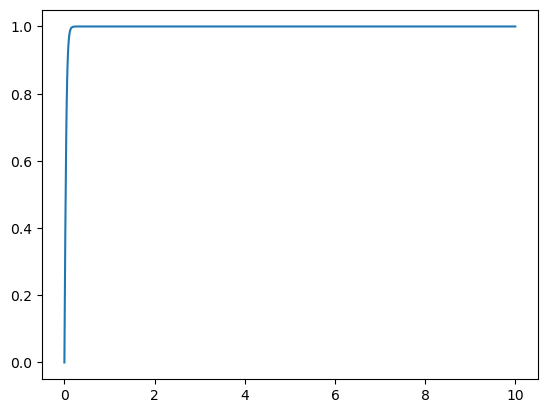

In [436]:
f=torch.tanh
ppp(f)

In [437]:
def softmax(x):
    """
    Computes the softmax function for a given numpy array.

    Args:
        x (numpy.ndarray): Input array.

    Returns:
        numpy.ndarray: Softmax output.
    """
    e_x = np.exp((x - np.max(x))) # Subtracting np.max(x) for numerical stability
    return e_x / e_x.sum(axis=0)

In [438]:
def pnormalize(x,p=2):
    """
    Computes the softmax function for a given numpy array.

    Args:
        x (numpy.ndarray): Input array.

    Returns:
        numpy.ndarray: Softmax output.
    """
    e_x = x**p # Subtracting np.max(x) for numerical stability
    return e_x #/ e_x.sum(axis=0)

In [439]:
E=np.array([[1,1,1,1],
[1,0,1,1],
[0,1,1,1],
[1,1,0,0]])

Pin=np.array([[0.8,0.2],
[0.2,0.8],
[0.8,0.2],
[0.8,0.2]])

C=np.array([[0,19],
[7,0]])

Pout=np.array([[0.2,0.8],
[0.2,0.8],
[0.8,0.2],
[0.8,0.2]])


needs=E@Pin
print(needs)
#needs[needs!=0]=1
needs=pnormalize(needs)

print(needs)
costs=Pout@C
print(costs)

res2=needs*costs
print(np.sum(res2,axis=1))


[[2.6 1.4]
 [2.4 0.6]
 [1.8 1.2]
 [1.  1. ]]
[[6.76 1.96]
 [5.76 0.36]
 [3.24 1.44]
 [1.   1.  ]]
[[ 5.6  3.8]
 [ 5.6  3.8]
 [ 1.4 15.2]
 [ 1.4 15.2]]
[45.304 33.624 26.424 16.6  ]


## Create topolgies

In [440]:
import numpy as np
import topologies
import networkx as nx
import yaml
import json

In [441]:
def create_maps_from_E(N,E):
    #maps=np.full((N,N),10e10) #  99
    maps=np.full((N,N),99) #  99
    for i in range(N):
        maps[i,i]=0
    for (i,j,v) in E:
        maps[i,j]=v
        maps[j,i]=v
    return maps


In [442]:
def create_yaml_file(N, model_type, maps):
    # valid: resnet18, resnet101
    if model_type == 'resnet18':
        layers_str = "[inputs, conv1.weight, layer1.0.conv1.weight, layer1.0.conv2.weight, layer1.1.conv1.weight, layer1.1.conv2.weight, layer2.0.conv1.weight, layer2.0.conv2.weight, layer2.0.shortcut.0.weight, layer2.1.conv1.weight, layer2.1.conv2.weight, layer3.0.conv1.weight, layer3.0.conv2.weight, layer3.0.shortcut.0.weight, layer3.1.conv1.weight, layer3.1.conv2.weight, layer4.0.conv1.weight, layer4.0.conv2.weight, layer4.0.shortcut.0.weight, layer4.1.conv1.weight, layer4.1.conv2.weight]"

    if model_type == 'resnet101':
        layers_str =  "[inputs, conv1.weight, layer1.0.conv1.weight, layer1.0.conv2.weight, layer1.1.conv1.weight, \
            layer1.1.conv2.weight, layer1.2.conv1.weight, layer1.2.conv2.weight, layer2.0.conv1.weight, \
            layer2.0.conv2.weight, layer2.0.shortcut.0.weight, layer2.1.conv1.weight, layer2.1.conv2.weight, \
            layer2.2.conv1.weight, layer2.2.conv2.weight, layer2.3.conv1.weight, layer2.3.conv2.weight, \
            layer3.0.conv1.weight, layer3.0.conv2.weight, layer3.0.shortcut.0.weight, layer3.1.conv1.weight, \
            layer3.1.conv2.weight, layer3.2.conv1.weight, layer3.2.conv2.weight, layer3.3.conv1.weight, \
            layer3.3.conv2.weight, layer3.4.conv1.weight, layer3.4.conv2.weight, layer3.5.conv1.weight, \
            layer3.5.conv2.weight, layer3.6.conv1.weight, layer3.6.conv2.weight, layer3.7.conv1.weight, \
            layer3.7.conv2.weight, layer3.8.conv1.weight, layer3.8.conv2.weight, layer3.9.conv1.weight, \
            layer3.9.conv2.weight, layer3.10.conv1.weight, layer3.10.conv2.weight, layer3.11.conv1.weight, \
            layer3.11.conv2.weight, layer3.12.conv1.weight, layer3.12.conv2.weight, layer3.13.conv1.weight, \
            layer3.13.conv2.weight, layer3.14.conv1.weight, layer3.14.conv2.weight, layer3.15.conv1.weight, \
            layer3.15.conv2.weight, layer3.16.conv1.weight, layer3.16.conv2.weight, layer3.17.conv1.weight, \
            layer3.17.conv2.weight, layer3.18.conv1.weight, layer3.18.conv2.weight, layer3.19.conv1.weight, \
            layer3.19.conv2.weight, layer3.20.conv1.weight, layer3.20.conv2.weight, layer3.21.conv1.weight, \
            layer3.21.conv2.weight, layer3.22.conv1.weight, layer3.22.conv2.weight, layer4.0.conv1.weight, \
            layer4.0.conv2.weight, layer4.0.shortcut.0.weight, layer4.1.conv1.weight, layer4.1.conv2.weight, \
            layer4.2.conv1.weight, layer4.2.conv2.weight]"  

    yaml_dict = {}
    yaml_dict['bn_partitions'] = [N] * 9
    initial_budget = [1] * N
    yaml_dict['budgets'] = np.tile(initial_budget, (20, 1)).tolist()
    yaml_dict['initial_budget'] = initial_budget
    yaml_dict['input_partition'] = initial_budget
    yaml_dict['layers'] = layers_str
    yaml_dict['maps'] = maps.tolist() #np.array2string(maps, threshold=10000)
    yaml_dict['num'] = N
    yaml_str = json.dumps(yaml_dict)

    yaml_str = yaml_str.replace("\"", "")
    yaml_str = yaml_str.replace(", budgets: ", "\nbudgets: ")
    yaml_str = yaml_str.replace(", initial_budget: ", "\ninitial_budget: ")
    yaml_str = yaml_str.replace(", input_partition: ", "\ninput_partition: ")
    yaml_str = yaml_str.replace(", layers: ", "\nlayers: ")
    yaml_str = yaml_str.replace(", maps: ", "\nmaps: ")
    yaml_str = yaml_str.replace(", num: ", "\nnum: ")
    yaml_str = yaml_str.replace("{", "")
    yaml_str = yaml_str.replace("}", "")
    '''
    yaml_str = yaml_str.replace(", '", "\n'")
    yaml_str = yaml_str.replace("{", "")
    yaml_str = yaml_str.replace("}", "")
    yaml_str = yaml_str.replace("array(", "")
    yaml_str = yaml_str.replace("]])", "]]")
    yaml_str = yaml_str.replace("],", "]\n")
    '''
    yaml_str = yaml_str.replace("layer1.1.conv1.weight,", "layer1.1.conv1.weight,\n")
    yaml_str = yaml_str.replace("layer2.0.shortcut.0.weight,", "layer2.0.shortcut.0.weight,\n")
    yaml_str = yaml_str.replace("layer3.0.conv2.weight,", "layer3.0.conv2.weight,\n")
    yaml_str = yaml_str.replace("layer4.0.conv1.weight,", "layer4.0.conv1.weight,\n")

    yaml_str = yaml_str.replace("layer1.1.conv2.weight,", "        layer1.1.conv2.weight,")
    yaml_str = yaml_str.replace("layer2.1.conv1.weight,", "        layer2.1.conv1.weight,")
    yaml_str = yaml_str.replace("layer3.0.shortcut.0.weight,", "        layer3.0.shortcut.0.weight,")
    yaml_str = yaml_str.replace("layer4.0.conv2.weight", "        layer4.0.conv2.weight")
    '''
    yaml_str = yaml_str.replace("\"", "")
    yaml_str = yaml_str.replace(", maps: ", "\nmaps: ")
    '''
    yaml_filename = "./config/" + model_type + "-np" + str(N) + "-" + experiment_name + "_cost.yaml"
    print(yaml_filename)
    with open(yaml_filename, 'w') as file:
        file.write(yaml_str)
    print(yaml_str)



In [443]:
model_type = 'resnet101' # valid: resnet18, resnet101
experiment_name = 'Uniform' # valid: GEANT, Dtelekom, Abilene, ServiceNetwork, WattsStrogatz, BarabasiAlbert

if experiment_name == 'GEANT':
    graph = topologies.GEANT()
if experiment_name == 'Dtelekom':
    graph = topologies.Dtelekom()
if experiment_name == 'Abilene':
    graph = topologies.Abilene()
if experiment_name == 'ServiceNetwork':
    graph = topologies.ServiceNetwork()
if experiment_name == 'WattsStrogatz':
    graph = nx.watts_strogatz_graph(n=10, k=4, p=0.5)
if experiment_name == 'BarabasiAlbert':
    graph = nx.barabasi_albert_graph(n=10, m=4)
if experiment_name == 'Uniform':
    graph = nx.complete_graph(n=8)

In [444]:
print(graph.number_of_nodes())
N = graph.number_of_nodes()
print(graph.number_of_edges())
print(list(graph.nodes))
print(list(graph.edges))


8
28
[0, 1, 2, 3, 4, 5, 6, 7]
[(0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7), (1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (1, 7), (2, 3), (2, 4), (2, 5), (2, 6), (2, 7), (3, 4), (3, 5), (3, 6), (3, 7), (4, 5), (4, 6), (4, 7), (5, 6), (5, 7), (6, 7)]


In [445]:
for (source,target) in list(graph.edges):
        #print(source)
        graph[source][target]['weight'] = 1

In [446]:
#change weights
np.random.seed(12)
speeds=[0.5,1.5,2.5]
speed_probs=[0.5,0.3,0.2]
speed={}
for s in list(graph.nodes):
    print(s,graph.degree(s))
    c=np.random.choice(speeds, 1, speed_probs)[0]
    speed[s]=c
for (source,target) in list(graph.edges):
        #print(source)
        graph[source][target]['weight'] = speed[source]+speed[target]


0 7
1 7
2 7
3 7
4 7
5 7
6 7
7 7


In [447]:
maps=nx.floyd_warshall_numpy(graph)
maps

array([[0., 4., 4., 5., 3., 3., 5., 4.],
       [4., 0., 3., 4., 2., 2., 4., 3.],
       [4., 3., 0., 4., 2., 2., 4., 3.],
       [5., 4., 4., 0., 3., 3., 5., 4.],
       [3., 2., 2., 3., 0., 1., 3., 2.],
       [3., 2., 2., 3., 1., 0., 3., 2.],
       [5., 4., 4., 5., 3., 3., 0., 4.],
       [4., 3., 3., 4., 2., 2., 4., 0.]])

In [448]:
create_yaml_file(N, model_type, maps)

./config/resnet101-np8-Uniform_cost.yaml
bn_partitions: [8, 8, 8, 8, 8, 8, 8, 8, 8]
budgets: [[1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1]]
initial_budget: [1, 1, 1, 1, 1, 1, 1, 1]
input_partition: [1, 1, 1, 1, 1, 1, 1, 1]
layers: [inputs, conv1.weight, layer1.0.conv1.weight, layer1.0.conv2.weight, layer1.1.conv1.weight,
                     layer1.1.conv2.weight, layer1.2.conv1.weight, layer1.2.conv2.weight, layer2.0.conv1.weight,             layer2.0.conv2.weight, layer2.0.shortcut.0.weight,
         layer2.1.conv1.wei

In [449]:
mapping = {}
i = 0
for node in list(graph.nodes):
    #print(node)
    mapping[node] = i
    i = i + 1
print(mapping)


{0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6, 7: 7}


In [450]:
new_graph= nx.relabel_nodes(graph, mapping)
print(list(new_graph.nodes))
print(list(new_graph.edges))
nodes = list(new_graph.nodes)
edges = list(new_graph.edges)

[0, 1, 2, 3, 4, 5, 6, 7]
[(0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7), (1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (1, 7), (2, 3), (2, 4), (2, 5), (2, 6), (2, 7), (3, 4), (3, 5), (3, 6), (3, 7), (4, 5), (4, 6), (4, 7), (5, 6), (5, 7), (6, 7)]


In [451]:

E = []
y = (1,)
for edge in edges:
    edge += y
    E.append(edge)
print(E)


[(0, 1, 1), (0, 2, 1), (0, 3, 1), (0, 4, 1), (0, 5, 1), (0, 6, 1), (0, 7, 1), (1, 2, 1), (1, 3, 1), (1, 4, 1), (1, 5, 1), (1, 6, 1), (1, 7, 1), (2, 3, 1), (2, 4, 1), (2, 5, 1), (2, 6, 1), (2, 7, 1), (3, 4, 1), (3, 5, 1), (3, 6, 1), (3, 7, 1), (4, 5, 1), (4, 6, 1), (4, 7, 1), (5, 6, 1), (5, 7, 1), (6, 7, 1)]


In [452]:

G = nx.Graph()
G.add_weighted_edges_from(E)
maps=nx.floyd_warshall_numpy(G)
maps


array([[0., 1., 1., 1., 1., 1., 1., 1.],
       [1., 0., 1., 1., 1., 1., 1., 1.],
       [1., 1., 0., 1., 1., 1., 1., 1.],
       [1., 1., 1., 0., 1., 1., 1., 1.],
       [1., 1., 1., 1., 0., 1., 1., 1.],
       [1., 1., 1., 1., 1., 0., 1., 1.],
       [1., 1., 1., 1., 1., 1., 0., 1.],
       [1., 1., 1., 1., 1., 1., 1., 0.]])

In [453]:

for (source,target) in list(G.edges):
        #print(source)
        G[source][target]['weight'] = 1


In [454]:

G[source][target]['weight'] = 1


In [455]:
#N=4
#E=[(0,1,1),(0,2,4),(2,3,1),(0,3,1)]
maps0 = create_maps_from_E(N,E)
maps0


array([[0, 1, 1, 1, 1, 1, 1, 1],
       [1, 0, 1, 1, 1, 1, 1, 1],
       [1, 1, 0, 1, 1, 1, 1, 1],
       [1, 1, 1, 0, 1, 1, 1, 1],
       [1, 1, 1, 1, 0, 1, 1, 1],
       [1, 1, 1, 1, 1, 0, 1, 1],
       [1, 1, 1, 1, 1, 1, 0, 1],
       [1, 1, 1, 1, 1, 1, 1, 0]])

In [456]:
maps

array([[0., 1., 1., 1., 1., 1., 1., 1.],
       [1., 0., 1., 1., 1., 1., 1., 1.],
       [1., 1., 0., 1., 1., 1., 1., 1.],
       [1., 1., 1., 0., 1., 1., 1., 1.],
       [1., 1., 1., 1., 0., 1., 1., 1.],
       [1., 1., 1., 1., 1., 0., 1., 1.],
       [1., 1., 1., 1., 1., 1., 0., 1.],
       [1., 1., 1., 1., 1., 1., 1., 0.]])

In [457]:
budget = [0,0,0,0.2,0.2,0.2,0.2,0.2]
shape = 64

In [458]:
def fixsum(a,shape):
    total=np.sum(a)
    dif=shape-total
    d=np.sign(dif)
    c=0
    for i in range(a.size):
        if c>=np.abs(dif):
            break
        if a[i]!=0:
            a[i]+=d
            c+=1
    return a

In [459]:
absolute_counts = np.round(np.array(budget) * shape).astype(int)
a=fixsum(absolute_counts,shape)

In [460]:
absolute_counts

array([ 0,  0,  0, 12, 13, 13, 13, 13])

In [461]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

## Recreate plots from png!


In [1]:
import pandas as pd
from plottable import ColumnDefinition, Table
import matplotlib.pyplot as plt
import os

In [2]:
df1 = pd.read_csv('test.csv')
new_cols = ['Dataset', 'Model', 'Topology', 'Partitions', 'Run', 'Prune Ratio',
       'Best Accuracy', 'Last Accuracy', 'Comm Cost', 'Eval Cost',
       'Aggregate Cost', 'Comm Cost(MB)']
df1.columns = new_cols
print(df1.shape)
df1

(4, 12)


,Dataset,Model,Topology,Partitions,Run,Prune Ratio,Best Accuracy,Last Accuracy,Comm Cost,Eval Cost,Aggregate Cost,Comm Cost(MB)
0,cifar100,resnet101,Dtelekom,68,partition row Dtelekom cost_rsgn5_original_agg...,0.85,74.39,74.36,15431264,8874848,6782208,61725.1
1,cifar100,resnet101,Dtelekom,68,partition row Dtelekom cost_rsgn5_original_agg...,1.00,42.77,42.55,0,33678480,27347136,0.0
2,cifar100,resnet101,Dtelekom,68,partition row Dtelekom cost_rsgn5_original_ful...,0.85,74.81,74.81,15431328,22014256,9487072,61725.3
3,cifar100,resnet101,Dtelekom,68,partition row Dtelekom cost_rsgn5_original_ful...,1.00,33.77,33.77,0,4105664,4099744,0.0


In [3]:
df_init = pd.read_csv('test_initial.csv') 
new_cols = ['Dataset', 'Model', 'Topology', 'Partitions', 'Run', 'Prune Ratio',
       'Best Accuracy', 'Last Accuracy', 'Comm Cost', 'Eval Cost',
       'Aggregate Cost', 'Comm Cost(MB)']
df_init.columns = new_cols
print(df_init.shape)
df_init

(13, 12)


,Dataset,Model,Topology,Partitions,Run,Prune Ratio,Best Accuracy,Last Accuracy,Comm Cost,Eval Cost,Aggregate Cost,Comm Cost(MB)
0,cifar100,resnet101,Dtelekom,68,partition row Dtelekom cost_rsgn5_original_agg...,0.00,70.17,70.17,99900416,55220064,40048768,399601.7
1,cifar100,resnet101,Dtelekom,68,partition row Dtelekom cost_rsgn5_original_agg...,0.50,75.60,75.60,50948528,35413056,25471328,203794.1
2,cifar100,resnet101,Dtelekom,68,partition row Dtelekom cost_rsgn5_original_agg...,0.75,71.27,71.19,25495936,9553936,4213456,101983.7
3,cifar100,resnet101,Dtelekom,68,partition row Dtelekom cost_rsgn5_original_agg...,0.85,70.12,69.87,15347888,11546944,7929664,61391.6
4,cifar100,resnet101,Dtelekom,68,partition row Dtelekom cost_rsgn5_original_agg...,1.00,38.41,38.02,0,91632512,25620272,0.0
5,cifar100,resnet101,Dtelekom,68,partition row Dtelekom cost_rsgn5_original_full 5,0.00,70.17,70.17,99900416,22294336,13453456,399601.7
6,cifar100,resnet101,Dtelekom,68,partition row Dtelekom cost_rsgn5_original_full 5,0.50,75.45,75.45,50948144,17481856,3929472,203792.6
7,cifar100,resnet101,Dtelekom,68,partition row Dtelekom cost_rsgn5_original_full 5,0.75,72.70,72.68,25550592,22419632,16051152,102202.4
8,cifar100,resnet101,Dtelekom,68,partition row Dtelekom cost_rsgn5_original_full 5,0.85,72.62,72.61,15293776,32045888,23513216,61175.1
9,cifar100,resnet101,Dtelekom,68,partition row Dtelekom cost_rsgn5_original_full 5,1.00,41.45,41.34,0,24853808,18851008,0.0


In [4]:
df = pd.concat([df1, df_init])
print(df.shape)
df


(17, 12)


,Dataset,Model,Topology,Partitions,Run,Prune Ratio,Best Accuracy,Last Accuracy,Comm Cost,Eval Cost,Aggregate Cost,Comm Cost(MB)
0,cifar100,resnet101,Dtelekom,68,partition row Dtelekom cost_rsgn5_original_agg...,0.85,74.39,74.36,15431264,8874848,6782208,61725.1
1,cifar100,resnet101,Dtelekom,68,partition row Dtelekom cost_rsgn5_original_agg...,1.00,42.77,42.55,0,33678480,27347136,0.0
2,cifar100,resnet101,Dtelekom,68,partition row Dtelekom cost_rsgn5_original_ful...,0.85,74.81,74.81,15431328,22014256,9487072,61725.3
3,cifar100,resnet101,Dtelekom,68,partition row Dtelekom cost_rsgn5_original_ful...,1.00,33.77,33.77,0,4105664,4099744,0.0
0,cifar100,resnet101,Dtelekom,68,partition row Dtelekom cost_rsgn5_original_agg...,0.00,70.17,70.17,99900416,55220064,40048768,399601.7
1,cifar100,resnet101,Dtelekom,68,partition row Dtelekom cost_rsgn5_original_agg...,0.50,75.60,75.60,50948528,35413056,25471328,203794.1
2,cifar100,resnet101,Dtelekom,68,partition row Dtelekom cost_rsgn5_original_agg...,0.75,71.27,71.19,25495936,9553936,4213456,101983.7
3,cifar100,resnet101,Dtelekom,68,partition row Dtelekom cost_rsgn5_original_agg...,0.85,70.12,69.87,15347888,11546944,7929664,61391.6
4,cifar100,resnet101,Dtelekom,68,partition row Dtelekom cost_rsgn5_original_agg...,1.00,38.41,38.02,0,91632512,25620272,0.0
5,cifar100,resnet101,Dtelekom,68,partition row Dtelekom cost_rsgn5_original_full 5,0.00,70.17,70.17,99900416,22294336,13453456,399601.7


In [11]:
df['Run']

0     partition row Dtelekom cost_rsgn5_original_agg...
1     partition row Dtelekom cost_rsgn5_original_agg...
2     partition row Dtelekom cost_rsgn5_original_ful...
3     partition row Dtelekom cost_rsgn5_original_ful...
0     partition row Dtelekom cost_rsgn5_original_agg...
1     partition row Dtelekom cost_rsgn5_original_agg...
2     partition row Dtelekom cost_rsgn5_original_agg...
3     partition row Dtelekom cost_rsgn5_original_agg...
4     partition row Dtelekom cost_rsgn5_original_agg...
5     partition row Dtelekom cost_rsgn5_original_full 5
6     partition row Dtelekom cost_rsgn5_original_full 5
7     partition row Dtelekom cost_rsgn5_original_full 5
8     partition row Dtelekom cost_rsgn5_original_full 5
9     partition row Dtelekom cost_rsgn5_original_full 5
10          kernel Dtelekom cost fixed_original_full 60
11          kernel Dtelekom cost fixed_original_full 60
12          kernel Dtelekom cost fixed_original_full 60
Name: Run, dtype: object

In [5]:
def plot_table_metrics(df, output_dir="."):
    datacodes = df["Dataset"]
    models = df["Model"]
    topologies = df["Topology"]
    partitions = df["Partitions"]
    exp_runs = df["Run"]
    prune_ratios = df["Prune Ratio"]
    accuracies = df["Best Accuracy"]
    latest_accuracies = df["Last Accuracy"]
    comm_costs = df["Comm Cost"]
    eval_costs = df["Eval Cost"]
    eval_cost_aggregates = df["Aggregate Cost"]
    kbs = df["Comm Cost(MB)"]

    dict = {'Dataset': datacodes, 'Model': models, 'Topology': topologies, 'Partitions': partitions, 
        'Run': exp_runs, 'Prune Ratio': prune_ratios, 'Best Accuracy': accuracies, 'Last Accuracy': latest_accuracies,
        'Comm Cost': comm_costs, 'Eval Cost': eval_costs, 'Aggregate Cost': eval_cost_aggregates, 'Comm Cost(MB)': kbs} 

    df = pd.DataFrame(dict)
    df = df.set_index("Dataset")
    #print(df)  

    colnames = [
        "Dataset",
        "Model"
        "Topology",
        "Partitions",
        "Run",
        "Prune Ratio",
        "Best Accuracy",
        "Last Accuracy",
        "Comm Cost",
        "Eval Cost",
        "Aggregate Cost",
        "Comm Cost(MB)",
    ]

    col_defs = (
    [
        ColumnDefinition(
            name="Dataset",
            textprops={"ha": "left"},
            width=0.35,
        ),
        ColumnDefinition(
            name="Model",
            textprops={"ha": "left"},
            width=0.35,
        ),
        ColumnDefinition(
            name="Topology",
            #group="Team Rating",
            textprops={"ha": "left"},
            width=0.35,
        ),
        ColumnDefinition(
            name="Partitions",
            textprops={"ha": "center"},
            width=0.35,
        ),
        ColumnDefinition(
            name="Run",
            textprops={"ha": "left"},
            width=2.5,
        ),
        ColumnDefinition(
            name="Prune Ratio",
            textprops={"ha": "center"},
            width=0.35,
        ),
        ColumnDefinition(
            name="Best Accuracy",
            #group="Team Rating",
            textprops={"ha": "center"},
            width=0.35,
        ),
        ColumnDefinition(
            name="Last Accuracy",
            #group="Team Rating",
            textprops={"ha": "center"},
            width=0.35,
        ),
        ColumnDefinition(
            name="Comm Cost",
            textprops={"ha": "left"},
            width=0.35,
        ),
        ColumnDefinition(
            name="Aggregate Cost",
            textprops={"ha": "center"},
            width=0.35,
        ),
        ColumnDefinition(
            name="Eval Cost",
            #group="Team Rating",
            textprops={"ha": "center"},
            width=0.35,
        ),
        ColumnDefinition(
            name="Comm Cost(MB)",
            #group="Team Rating",
            textprops={"ha": "center"},
            width=0.35,
        ),
    ])

    plt.rcParams["font.family"] = ["DejaVu Sans"]
    plt.rcParams["savefig.bbox"] = "tight"

    fig, ax = plt.subplots(figsize=(25, 14))
    fig.suptitle(f"Experiments' Metrics", fontsize=10, y=0.9)

    table = Table(
        df,
        column_definitions=col_defs,
        #row_dividers=True,
        #footer_divider=True,
        ax=ax,
        textprops={"fontsize": 10},
        #row_divider_kw={"linewidth": 0.5, "linestyle": (0, (1, 5))},
        #col_label_divider_kw={"linewidth": 0.5, "linestyle": "-"},
        #column_border_kw={"linewidth": 0.5, "linestyle": "-"},
    )#.autoset_fontcolors(colnames=["OFF", "DEF"])

    save_fname = os.path.join(
            output_dir,
            f"experiments_metrics.png"
        )
    fig.savefig(save_fname, facecolor=ax.get_facecolor(), dpi=200)
    return 


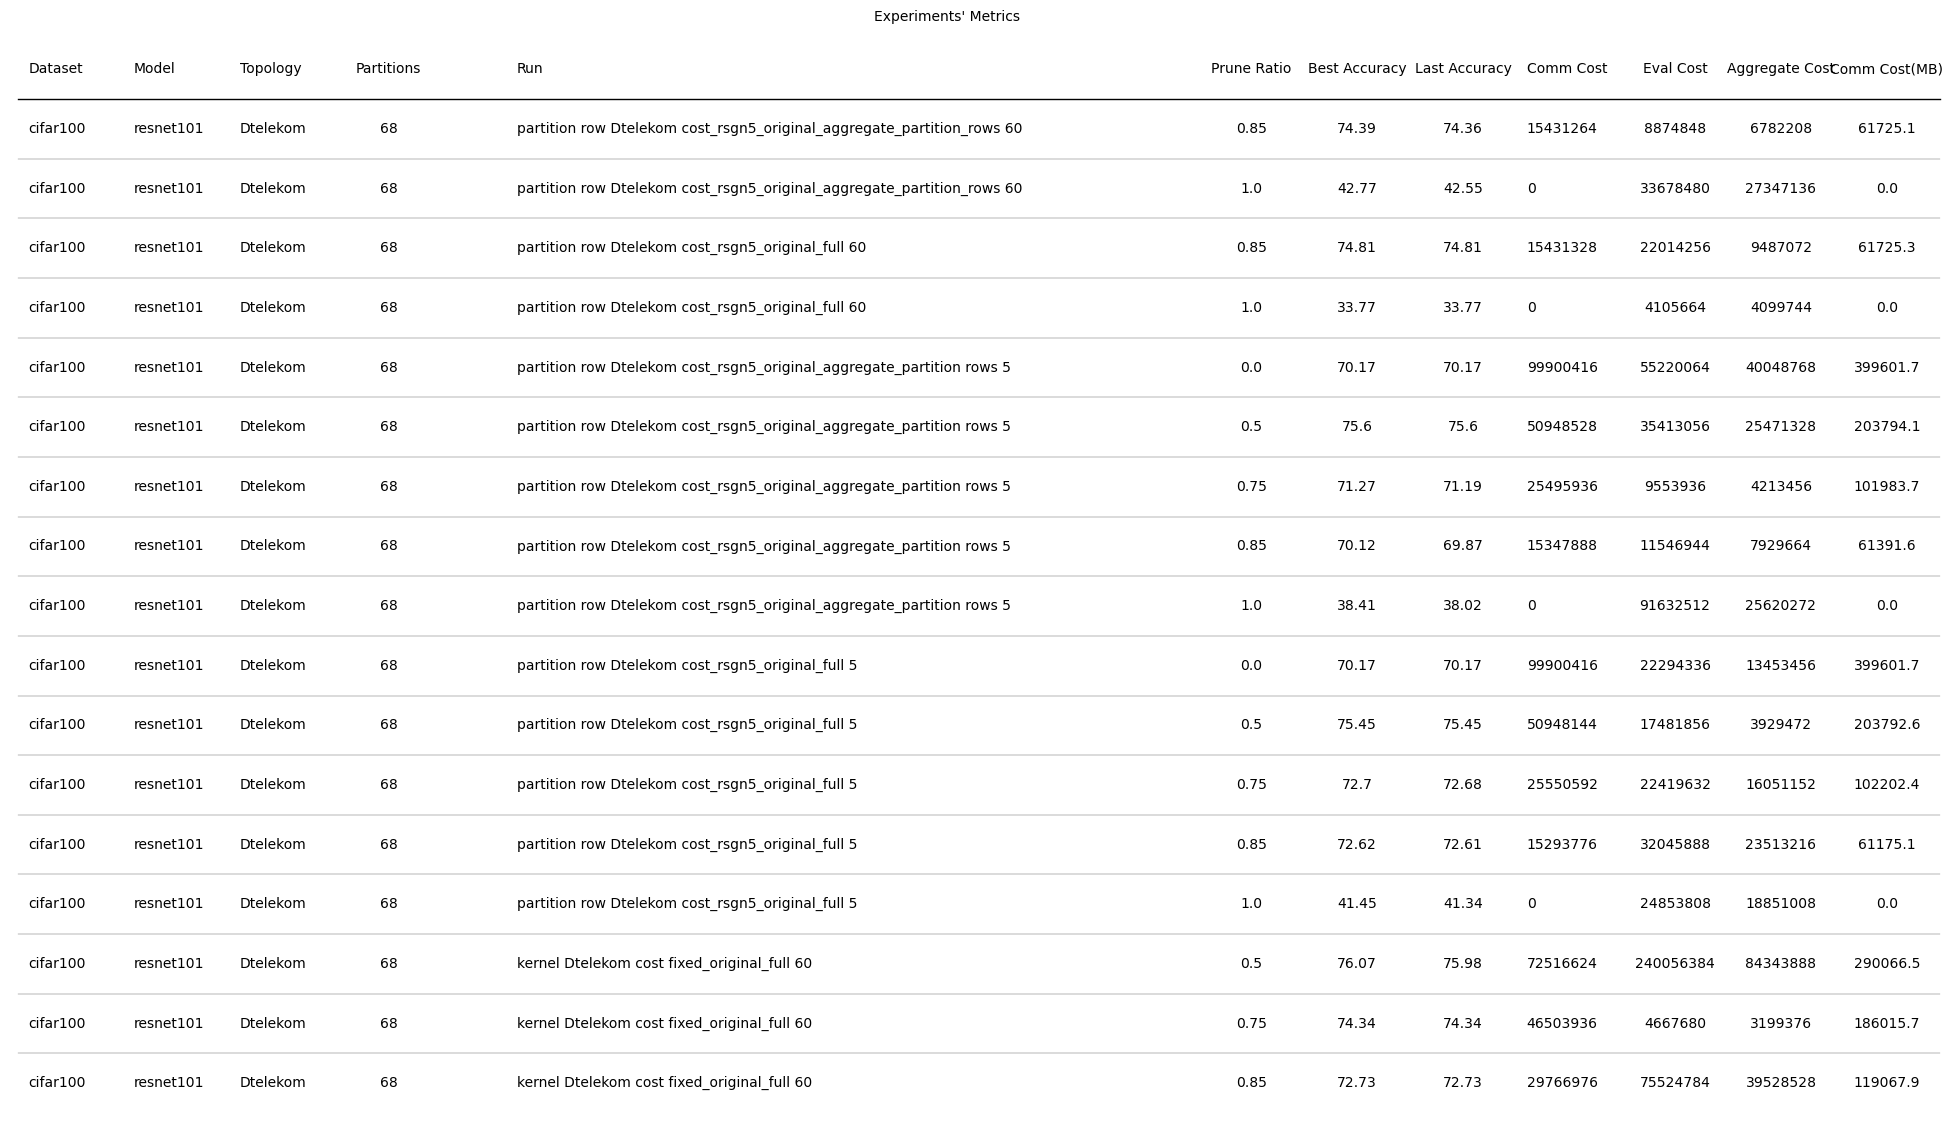

In [6]:
plot_table_metrics(df, output_dir=".")

In [9]:
from pareto import *

/home/davarakis.t/proect2/CaP2/pareto.py:983: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_state_path, map_location=torch.device('cpu

Saved figure to experiment_logs_barabasi_albert_costs/cifar100_resnet101_10_rows_metrics.png
Saved figure to experiment_logs_barabasi_albert_costs/cifar100_resnet101_10_full_metrics.png
Saved figure to experiment_logs_barabasi_albert_costs/cifar100_resnet101_10_BarabasiAlbert_metrics.png
✅  Visualizations saved!


defaultdict(<function pareto.generate_visualizations.<locals>.<lambda>()>,
            {('cifar100',
              'resnet101',
              '10',
              'BarabasiAlbert'): defaultdict(list,
                         {'partition_row_BarabasiAlbert_cost_rsgn5_original_aggregate_partition_rows_10': [(0.0,
                            70.17,
                            13814784,
                            28403101.968066264,
                            55259.13600009263,
                            0.0,
                            50940288.0,
                            6119616.0,
                            70.17),
                           (0.5,
                            76.32,
                            6994944,
                            208699541.36403805,
                            27979.77600001537,
                            0.4533476269985833,
                            23216000.0,
                            3577760.0,
                            76.32),
         

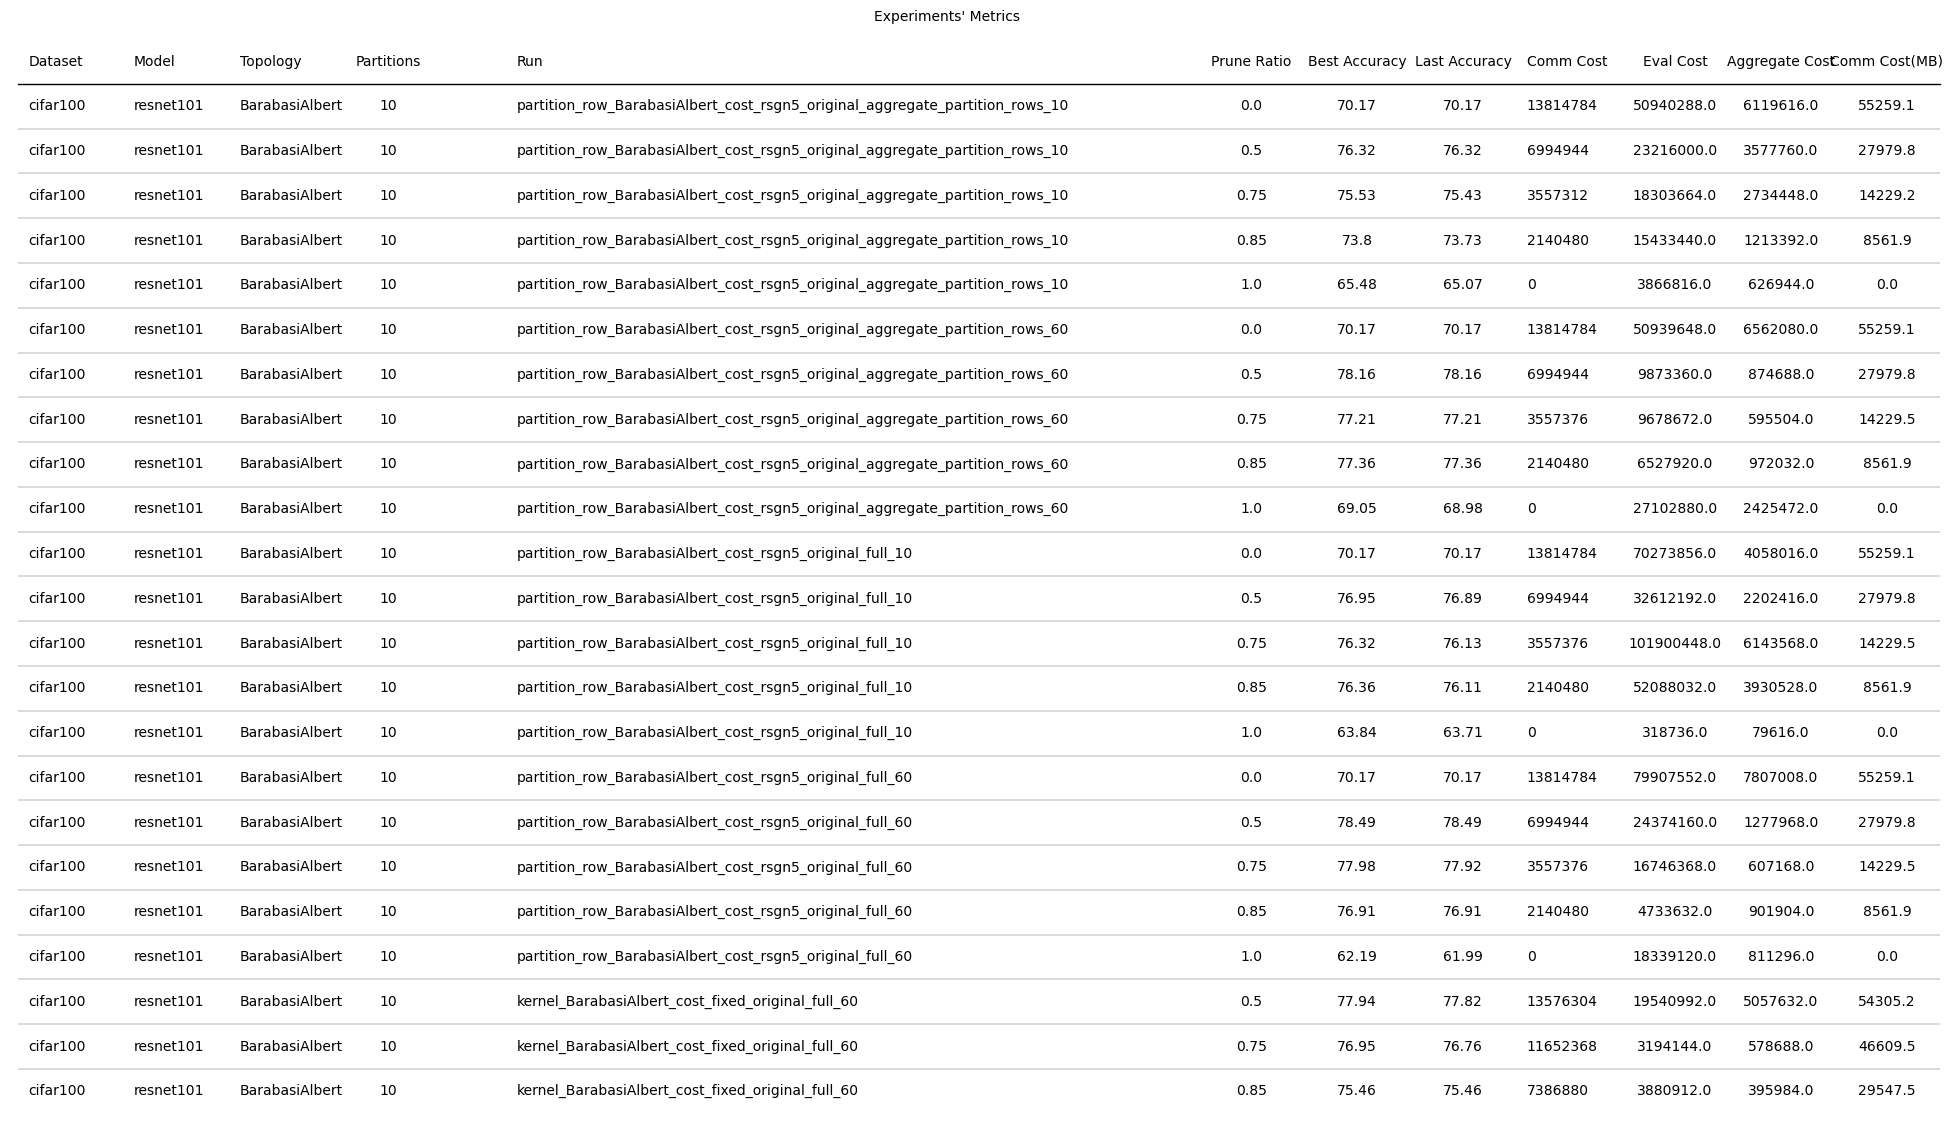

In [10]:
experiment_logs_path = "experiment_logs_barabasi_albert_costs"
#code = "cifar10"        # valid cifar10, cifar100
#dataset_root = "./assets/data"
#generate_visualizations(experiment_logs_path, code, dataset_root, gen_images=False, sparsity_mode="kernel")
generate_visualizations(experiment_logs_path, gen_images=False, sparsity_mode="kernel")

In [ ]:
#def plot_all_metrics(experiments, output_dir=".", sparsity_mode="kernel"):
"""
We assume 'experiments' is a dict:
    experiments = {
        key: {   # e.g. (data_code, model, np, exp_flag)
        reassign_flag: [
            (prune_ratio, best_acc, comm_cost, comm_loss, total_kbits, model_sparsity),
            ...
        ],
        ...
        },
        ...
    }

Produces a single 2x2 figure for each `key`:
    (1) Accuracy vs. Comm. Cost   (top-left)
    (2) Accuracy vs. Comm. Loss   (top-right)
    (3) Accuracy vs. Kbits        (bottom-left)
    (4) Sparsity vs. Kbits        (bottom-right)
    
The formulas added in the subplot titles are:

    Comm. Cost:
    Cost(W,M) = sum_{l=1}^L sum_{j=1}^{n_l} sum_{p != M(j)} c_{p,M(j)} * 1{exists i : W_l(i,j) != 0 and M(i)=p}

    Comm. Loss:
    Loss(W,M) = sum_{l=1}^L sum_{(i,j) in E_l} c_{M(i), M(j)} * |W_l(i,j)|

Each line is plotted in a color from your 'colors' list, based on the index of reassign_flag.
"""

# Custom color cycle for each reassign_flag line
colors = ["#FFC20A", "#0C7BDC", "#D41159", "#004D40", "#45D86E", "#3E2717", "#FE7800"]
markers = ['.', '*', 'v']
linestyles = ['-', '--', '-.', ':']

for key, reassignments in experiments.items():
    
    key_string = "_".join(key[:])
    
    # Create a new 2x2 figure
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 10))

    # axes[0,0] => Accuracy vs. Comm. Cost
    # axes[0,1] => Accuracy vs. Comm. Loss
    # axes[1,0] => Accuracy vs. Kbits
    # axes[1,1] => Sparsity vs. Kbits
    
    # For the cost, we use a “free-channels” logic expression, e.g.:
    #   Cost(W,M) = sum_{l=1 to L} sum_{j=1}^{n_l} sum_{p != M(j)} c_{p,M(j)}
    #        * 1{there exists i: W_l(i,j) != 0 and M(i)=p}
    #
    # For the loss, we sum over edges with absolute weights:
    #   Loss(W,M) = sum_{l=1}^L sum_{(i,j) in E_l} c_{M(i), M(j)} * |W_l(i,j)|

    # Convert axes to friendly names
    ax_cost  = axes[0,0]
    ax_loss  = axes[0,1]
    ax_kbits = axes[1,0]
    ax_spars = axes[1,1]
    
    legend_entries = []
    
    for idx, (reassign_flag, runs) in enumerate(reassignments.items()):
        marker = markers[0] if 'fixed' in reassign_flag else markers[1]
        # If you want to add a highlight line
        marker = markers[2] if 'prune_comm' in reassign_flag else marker
        linestyle = linestyles[1] if 'partition_row' in reassign_flag else linestyles[0]
        #print(reassign_flag, runs)
        runs_sorted = sorted(runs, key=lambda x: x[0])  # sort by prune_ratio
        pr_vals, acc_vals, cost_vals, loss_vals, kbits_vals, spar_vals, latest_acc_vals = map(lambda vals: [to_float(v) for v in vals], zip(*runs_sorted))

        # Pick a color from the custom list
        color = colors[idx % len(colors)]
        legend_entries.append((linestyle, marker, color, reassign_flag))

        # 1) Accuracy vs. Comm. Cost
        ax_cost.plot(cost_vals, acc_vals, marker=marker, markersize=12, linestyle=linestyle, 
                        label=f"{reassign_flag}", color=color)
        for i, prr in enumerate(pr_vals):
            ax_cost.text(cost_vals[i], acc_vals[i], f"pr={prr}", fontsize=10)

        # 2) Accuracy vs. Comm. Loss
        ax_loss.plot(loss_vals, acc_vals, marker=marker, markersize=12, linestyle=linestyle, 
                        label=f"{reassign_flag}", color=color)
        for i, prr in enumerate(pr_vals):
            ax_loss.text(loss_vals[i], acc_vals[i], f"pr={prr}", fontsize=10)

        # 3) Accuracy vs. Kbits
        ax_kbits.plot(kbits_vals, acc_vals, marker=marker, markersize=12, linestyle=linestyle, 
                        label=f"{reassign_flag}", color=color)
        for i, prr in enumerate(pr_vals):
            ax_kbits.text(kbits_vals[i], acc_vals[i], f"pr={prr}", fontsize=10)

        # 4) Sparsity vs. Kbits
        ax_spars.plot(kbits_vals, spar_vals, marker=marker, markersize=12, linestyle=linestyle, 
                        label=f"{reassign_flag}", color=color)
        for i, prr in enumerate(pr_vals):
            ax_spars.text(kbits_vals[i], spar_vals[i], f"pr={prr}", fontsize=10)

    # ----------------------------------------------------------------
    # Titles with LaTeX formulas for Comm. Cost & Comm. Loss
    # ----------------------------------------------------------------

    # Top-left: Comm. Cost formula
    ax_cost.set_title(
        "Accuracy vs. Comm. Cost\n" +
        r"$\mathrm{Cost}(\mathbf{W},\mathbf{M}) = "
        r"\sum_{l=1}^{L}\sum_{j=1}^{n_l}\sum_{p\neq \mathbf{M}(j)}"
        r" c_{p,\mathbf{M}(j)} \cdot 1_{\{\exists i : W_l(i,j)\neq 0,\,M(i)=p\}}$"
    )

    ax_loss.set_title(
        "Accuracy vs. Comm. Loss\n" +
        r"$\mathrm{Loss}(\mathbf{W},\mathbf{M}) = "
        r"\sum_{l=1}^{L}\sum_{(i,j)\in E_l} "
        r"c_{M(i), M(j)} \cdot |W_l(i,j)|$"
    )

    # Bottom-left: Accuracy vs Kbits
    ax_kbits.set_title("Accuracy vs. Kbits Transmitted")
    # Bottom-right: Sparsity vs Kbits
    ax_spars.set_title(f"{sparsity_mode.capitalize()} Sparsity vs. Kbits")

    # ----------------------------------------------------------------
    # Axis labels, grid, legend, etc.
    # ----------------------------------------------------------------

    # Top-left
    ax_cost.set_xlabel("Comm. Cost")
    ax_cost.set_ylabel("Accuracy (%)")
    ax_cost.grid(True)
    #ax_cost.legend()

    # Top-right
    ax_loss.set_xlabel("Comm. Loss")
    ax_loss.set_ylabel("Accuracy (%)")
    ax_loss.grid(True)
    #ax_loss.legend()

    # Bottom-left
    ax_kbits.set_xlabel("Kbits Transmitted")
    ax_kbits.set_ylabel("Accuracy (%)")
    ax_kbits.grid(True)
    #ax_kbits.legend()

    # Bottom-right
    ax_spars.set_xlabel("Kbits Transmitted")
    ax_spars.set_ylabel(f"{sparsity_mode.capitalize()} Sparsity")
    ax_spars.grid(True)
    #ax_spars.legend()
    
    # Create a single legend further below the plots
    #print(legend_entries)
    handles = [plt.Line2D([0], [0], linestyle=style, marker=mark, color=col, markersize=10, label=lbl) 
                for style, mark, col, lbl in legend_entries]
    fig.legend(handles=handles, loc='lower center', fontsize=14, ncol=4, bbox_to_anchor=(0.5, -0.08))
    
    # Optional figure-level title referencing `key`
    fig.suptitle(f"All Metrics for {key_string}", fontsize=14, y=0.9)

    plt.tight_layout(rect=[0, 0, 1, 0.90])  # leaves space for suptitle

    # Save the figure
    save_fname = os.path.join(
        output_dir,
        f"{key_string}_metrics.png"
    )
    plt.savefig(save_fname, bbox_inches='tight')
    plt.close()
    print(f"Saved figure to {save_fname}")
